## Imports

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Structure and shape

In [44]:
test=pd.read_csv('test.csv')
train=pd.read_csv('train.csv')

In [45]:
test.shape[0]

418

In [46]:

test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [47]:
train.shape[0]

891

In [48]:

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [49]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [50]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


### Pre Processing

In [51]:
test.drop(columns=['PassengerId','Cabin'],inplace=True)

In [52]:
train.drop(columns=['PassengerId','Cabin'],inplace=True)

In [53]:
train.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Embarked      2
dtype: int64

In [54]:
test.isnull().sum()

Pclass       0
Name         0
Sex          0
Age         86
SibSp        0
Parch        0
Ticket       0
Fare         1
Embarked     0
dtype: int64

In [55]:
train['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [56]:
train['Embarked'] = train['Embarked'].fillna('S')

In [57]:
train['Embarked'].isnull().sum()

np.int64(0)

In [58]:
train.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Embarked      0
dtype: int64

In [59]:
train['Fare'] = train['Fare'].fillna(train['Fare'].mean())

In [60]:
test['Fare'] = test['Fare'].fillna(test['Fare'].mean())

In [61]:
train.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Embarked      0
dtype: int64

In [62]:
test.isnull().sum()

Pclass       0
Name         0
Sex          0
Age         86
SibSp        0
Parch        0
Ticket       0
Fare         0
Embarked     0
dtype: int64

In [63]:
train_Age=np.random.randint(train['Age'].mean()-train['Age'].std(),train['Age'].mean()+train['Age'].std(),177)

In [64]:
test_Age=np.random.randint(test['Age'].mean()-test['Age'].std(),test['Age'].mean()+test['Age'].std(),177)

In [65]:
print(train_Age)

[39 36 24 21 31 18 25 39 18 28 30 31 32 20 15 36 25 22 33 42 17 42 29 23
 24 39 28 39 19 35 18 36 20 33 34 32 19 17 32 36 31 32 43 42 29 15 39 17
 25 21 21 22 20 37 19 40 33 25 37 29 18 28 39 35 40 41 42 19 33 34 36 41
 38 36 27 24 24 29 18 34 22 25 34 22 38 28 33 17 33 34 18 18 38 38 17 38
 29 20 27 33 40 33 34 27 25 41 19 34 40 37 22 19 38 28 17 36 39 41 21 33
 21 29 42 18 25 36 16 33 15 23 16 39 39 18 42 24 43 32 39 24 24 20 32 18
 27 27 26 29 26 38 35 27 21 30 17 15 27 26 15 21 18 39 24 33 27 22 16 37
 17 37 29 42 27 24 39 23 16]


In [66]:
print(test_Age)

[17 29 17 16 42 38 20 20 38 35 31 39 32 25 36 35 27 42 40 19 39 31 30 29
 42 26 29 37 33 23 18 38 24 43 27 17 20 27 22 24 26 40 40 35 30 31 42 20
 39 31 31 39 30 39 16 39 22 34 39 17 24 33 18 42 17 16 23 24 36 16 35 24
 24 35 39 29 23 26 32 33 37 19 40 24 34 22 33 43 31 22 29 35 37 37 26 41
 20 41 41 39 18 22 19 35 39 34 33 29 16 37 18 21 28 22 18 28 26 17 19 24
 41 19 21 39 40 29 43 32 19 21 41 33 16 37 22 31 39 30 40 34 25 34 32 22
 30 42 25 23 41 31 18 35 37 39 42 22 32 36 21 16 23 22 17 39 17 40 33 43
 24 30 32 33 43 22 25 35 26]


In [67]:

train.loc[train['Age'].isnull(),'Age']=train_Age.mean()

In [68]:
test.loc[test['Age'].isnull(),'Age']=test_Age.mean()

In [69]:
train.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

In [70]:
test.isnull().sum()

Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

## EDA

In [71]:
def Survive_ratio(train, x):
    return train[train['Pclass']==x]['Survived'].value_counts()
for i in range(1,4):
    print(Survive_ratio(train, i))

Survived
1    136
0     80
Name: count, dtype: int64
Survived
0    97
1    87
Name: count, dtype: int64
Survived
0    372
1    119
Name: count, dtype: int64


In [72]:
train.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [73]:
train.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [74]:
train.groupby('Embarked')['Survived'].mean()

Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64

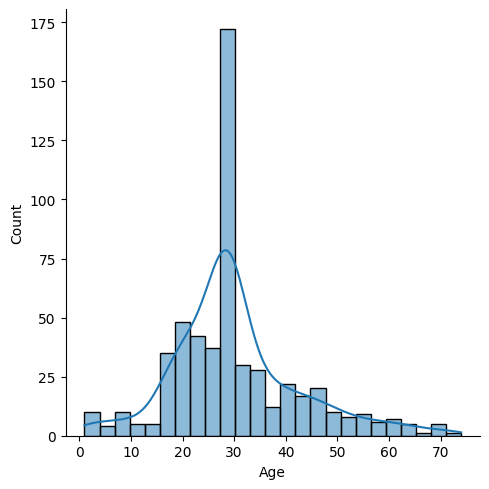

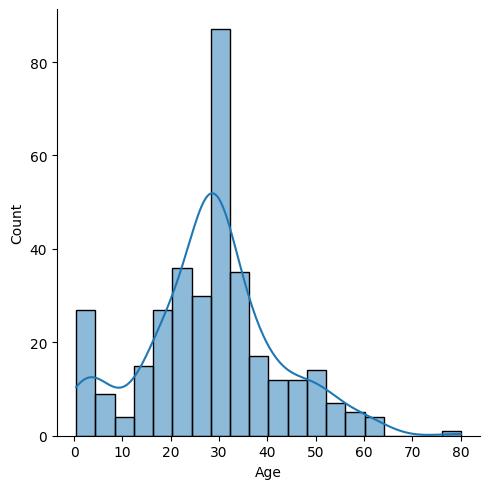

In [75]:
sns.displot(train['Age'][train['Survived']==0],kde=True)
sns.displot(train['Age'][train['Survived']==1],kde=True)

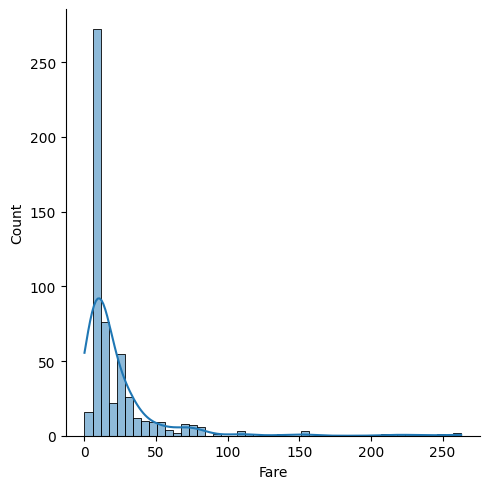

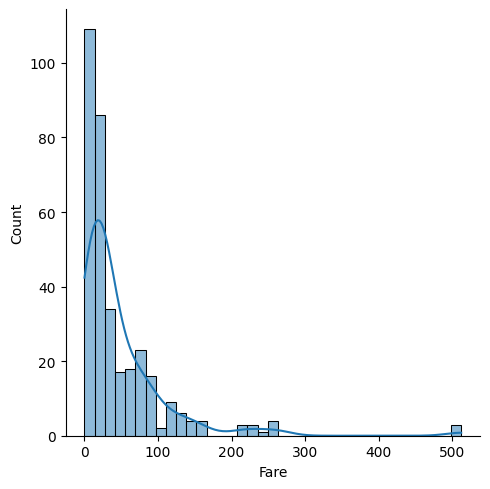

In [76]:
sns.displot(train['Fare'][train['Survived']==0],kde=True)
sns.displot(train['Fare'][train['Survived']==1],kde=True)

In [77]:
train.drop(columns=['Ticket'],inplace=True)
test.drop(columns=['Ticket'],inplace=True)

In [78]:
train['family_size']=train['SibSp']+train['Parch']+1

In [79]:
train['family_size'].value_counts()

family_size
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

In [80]:
test['family_size']=test['SibSp']+test['Parch']+1

In [81]:
test['family_size'].value_counts()

family_size
1     253
2      74
3      57
4      14
5       7
7       4
11      4
6       3
8       2
Name: count, dtype: int64

In [82]:
train.groupby(['family_size'])['Survived'].mean()

family_size
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

In [84]:
def calculate(num):
    if num==1:
        return "Alone"
    elif num>1 and num<5:
        return "Medium"
    else:
        return "Large"

In [85]:

train['Family_size_category']=train['family_size'].apply(calculate)

In [86]:
train['Family_size_category'].value_counts()

Family_size_category
Alone     537
Medium    292
Large      62
Name: count, dtype: int64

In [87]:
test['Family_size_category']=test['family_size'].apply(calculate)

In [88]:
test.head(2)

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,family_size,Family_size_category
0,3,"Kelly, Mr. James",male,34.5,0,0,7.8292,Q,1,Alone
1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,7.0000,S,2,Medium
